In [259]:
import numpy as np
import pandas as pd
import tabula 
import jpype

In [260]:
doc = tabula.read_pdf(
    "NCRB_STATS.pdf",
    pages="all",
    multiple_tables=True,
    force_subprocess=True,
    encoding="latin-1"
)

In [261]:
# no. of tables
print(type(doc))
print(len(doc))

<class 'list'>
495


In [262]:
doc[37].head()

,Unnamed: 0,Unnamed: 1,Offences affecting the Human Body
0,NaN,NaN,Assault on Women with Intent to Hurt
1,NaN,NaN,Outrage her Modesty
2,NaN,NaN,Grievous Hurt Wrongful
3,SL State/UT,NaN,Restraint/Confinement Assault on Women with In...
4,NaN,NaN,G) Other Grievous Hurt (Sec.341 to 348 IPC) Ou...


In [263]:
#getting tables 
for i in range(20):
    print(f"\nTable {i}")
    print(doc[i].shape)


Table 0
(3, 10)

Table 1
(0, 3)

Table 2
(3, 3)

Table 3
(0, 2)

Table 4
(13, 4)

Table 5
(18, 5)

Table 6
(11, 6)

Table 7
(22, 8)

Table 8
(10, 7)

Table 9
(8, 7)

Table 10
(0, 1)

Table 11
(8, 1)

Table 12
(7, 8)

Table 13
(9, 8)

Table 14
(24, 6)

Table 15
(9, 5)

Table 16
(38, 9)

Table 17
(38, 9)

Table 18
(38, 9)

Table 19
(36, 9)


In [264]:
#filtering out junk tables
for i, table in enumerate(doc):
    if len(table) > 20:  # more than 20 rows
        print(f"Table {i}: {table.shape}")

Table 7: (22, 8)
Table 14: (24, 6)
Table 16: (38, 9)
Table 17: (38, 9)
Table 18: (38, 9)
Table 19: (36, 9)
Table 20: (32, 9)
Table 21: (32, 9)
Table 22: (33, 9)
Table 23: (39, 8)
Table 25: (39, 8)
Table 26: (39, 8)
Table 27: (49, 5)
Table 28: (50, 3)
Table 29: (49, 5)
Table 30: (48, 6)
Table 31: (47, 5)
Table 32: (50, 7)
Table 33: (53, 4)
Table 34: (53, 4)
Table 35: (53, 4)
Table 36: (52, 5)
Table 37: (51, 3)
Table 38: (51, 3)
Table 39: (51, 4)
Table 40: (49, 3)
Table 41: (51, 4)
Table 42: (51, 3)
Table 43: (50, 5)
Table 44: (49, 3)
Table 45: (47, 5)
Table 46: (49, 5)
Table 47: (47, 5)
Table 48: (50, 8)
Table 49: (48, 9)
Table 50: (48, 10)
Table 51: (48, 9)
Table 52: (50, 9)
Table 53: (51, 4)
Table 54: (50, 4)
Table 55: (48, 5)
Table 56: (48, 5)
Table 57: (49, 5)
Table 58: (49, 4)
Table 59: (50, 5)
Table 60: (48, 5)
Table 61: (50, 3)
Table 62: (49, 3)
Table 63: (51, 5)
Table 64: (50, 3)
Table 65: (50, 4)
Table 66: (51, 5)
Table 67: (51, 3)
Table 68: (51, 5)
Table 69: (47, 5)
Table 70: 

In [265]:
type(doc[37])

pandas.core.frame.DataFrame

In [266]:
doc[7]

,S.\rNo.,Year,Total IPC Crimes,S.\rNo..1,Year.1,Total IPC Crimes.1,Unnamed: 0,Unnamed: 1
0,NaN,NaN,Crime\rIncidence,Crime\rRate,Charge-\rsheeting\rRate,Crime\rIncidence,Crime Rate,Charge-\rsheeting\rRate
1,1.0,1981.0,1385757200.861.3,22,2002,1780330169.580.0,NaN,NaN
2,2.0,1982.0,1353904192.065.3,23,2003,1716120160.780.1,NaN,NaN
3,3.0,1983.0,1349866187.467.3,24,2004,1832015168.879.8,NaN,NaN
4,4.0,1984.0,1358660184.767.9,25,2005,1822602165.380.7,NaN,NaN
5,5.0,1985.0,1384731184.470.2,26,2006,1878293167.780.6,NaN,NaN
6,6.0,1986.0,1405835183.571.1,27,2007,1989673175.180.1,NaN,NaN
7,7.0,1987.0,1406992180.172.4,28,2008,2093379181.579.8,NaN,NaN
8,8.0,1988.0,1440356180.870.7,29,2009,2121345181.478.4,NaN,NaN
9,9.0,1989.0,1529844188.572.3,30,2010,2224831187.679.1,NaN,NaN


In [267]:
def clean_table(df):
    df = df.dropna(how='all')
    df = df.dropna(axis=1, how='all')
    df = df.ffill()
    return df

In [268]:
df=clean_table(doc[37])

In [269]:
df = df.iloc[9:37]
df = df.reset_index(drop=True)

print(df.head())

            Unnamed: 0     Offences affecting the Human Body
0     1 Andhra Pradesh  2 2 0.0 1800 1849 3.4 5884 6118 22.2
1  2 Arunachal Pradesh             3 3 0.2 1 1 0.1 67 77 8.9
2              3 Assam  94 94 0.3 148 162 0.4 1984 2168 11.4
3              4 Bihar       281 283 0.2 0 0 0.0 402 403 0.7
4       5 Chhattisgarh     3 3 0.0 109 109 0.4 1322 1329 8.9


In [270]:
print(df.iloc[0].to_string())

Unnamed: 0                                               1 Andhra Pradesh
Offences affecting the Human Body    2 2 0.0 1800 1849 3.4 5884 6118 22.2


In [271]:
import re

df["State"] = df["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)

print(df[["State"]].head())

               State
0     Andhra Pradesh
1  Arunachal Pradesh
2              Assam
3              Bihar
4       Chhattisgarh


In [272]:
df["Offences affecting the Human Body"].head()

0    2 2 0.0 1800 1849 3.4 5884 6118 22.2
1               3 3 0.2 1 1 0.1 67 77 8.9
2    94 94 0.3 148 162 0.4 1984 2168 11.4
3         281 283 0.2 0 0 0.0 402 403 0.7
4       3 3 0.0 109 109 0.4 1322 1329 8.9
Name: Offences affecting the Human Body, dtype: object

In [273]:
crime_cols = df["Offences affecting the Human Body"].str.split(
    expand=True
)

print(crime_cols.head())

     0    1    2     3     4    5     6     7     8
0    2    2  0.0  1800  1849  3.4  5884  6118  22.2
1    3    3  0.2     1     1  0.1    67    77   8.9
2   94   94  0.3   148   162  0.4  1984  2168  11.4
3  281  283  0.2     0     0  0.0   402   403   0.7
4    3    3  0.0   109   109  0.4  1322  1329   8.9


In [274]:
final_df = pd.concat(
    [df["State"], crime_cols],
    axis=1
)

print(final_df.head())

cols = final_df.columns.drop("State")

final_df[cols] = final_df[cols].apply(
    pd.to_numeric,
    errors="coerce"
)


               State    0    1    2     3     4    5     6     7     8
0     Andhra Pradesh    2    2  0.0  1800  1849  3.4  5884  6118  22.2
1  Arunachal Pradesh    3    3  0.2     1     1  0.1    67    77   8.9
2              Assam   94   94  0.3   148   162  0.4  1984  2168  11.4
3              Bihar  281  283  0.2     0     0  0.0   402   403   0.7
4       Chhattisgarh    3    3  0.0   109   109  0.4  1322  1329   8.9


In [275]:
print(doc[37].iloc[:9].to_string())

    Unnamed: 0  Unnamed: 1                                        Offences affecting the Human Body
0          NaN         NaN                                     Assault on Women with Intent to Hurt
1          NaN         NaN                                                      Outrage her Modesty
2          NaN         NaN                                                   Grievous Hurt Wrongful
3  SL State/UT         NaN                    Restraint/Confinement Assault on Women with Intent to
4          NaN         NaN  G) Other Grievous Hurt (Sec.341 to 348 IPC) Outrage her Modesty (Total)
5          NaN         NaN                                                     (Sec.329, 331 & 335)
6          NaN         NaN                                                        I V R I V R I V R
7      [1] [2]         NaN                           [93] [94] [95] [96] [97] [98] [99] [100] [101]
8      STATES:         NaN                                                                      NaN


In [276]:
print(doc[37].iloc[:9].to_string())

    Unnamed: 0  Unnamed: 1                                        Offences affecting the Human Body
0          NaN         NaN                                     Assault on Women with Intent to Hurt
1          NaN         NaN                                                      Outrage her Modesty
2          NaN         NaN                                                   Grievous Hurt Wrongful
3  SL State/UT         NaN                    Restraint/Confinement Assault on Women with Intent to
4          NaN         NaN  G) Other Grievous Hurt (Sec.341 to 348 IPC) Outrage her Modesty (Total)
5          NaN         NaN                                                     (Sec.329, 331 & 335)
6          NaN         NaN                                                        I V R I V R I V R
7      [1] [2]         NaN                           [93] [94] [95] [96] [97] [98] [99] [100] [101]
8      STATES:         NaN                                                                      NaN


In [277]:
print(df.shape)

(28, 3)


In [278]:
print(df.columns.tolist())

['Unnamed: 0', 'Offences affecting the Human Body', 'State']


In [279]:
print(repr(df.iloc[0]["Offences affecting the Human Body"]))

'2 2 0.0 1800 1849 3.4 5884 6118 22.2'


In [280]:
crime_cols = (
    df["Offences affecting the Human Body"]
    .str.split(expand=True)
)

In [281]:
print(crime_cols.head())

     0    1    2     3     4    5     6     7     8
0    2    2  0.0  1800  1849  3.4  5884  6118  22.2
1    3    3  0.2     1     1  0.1    67    77   8.9
2   94   94  0.3   148   162  0.4  1984  2168  11.4
3  281  283  0.2     0     0  0.0   402   403   0.7
4    3    3  0.0   109   109  0.4  1322  1329   8.9


In [282]:
crime_cols.columns = [
    "Assault_I",
    "Assault_V",
    "Assault_R",
    "Modesty_I",
    "Modesty_V",
    "Modesty_R",
    "Grievous_I",
    "Grievous_V",
    "Grievous_R"
]

In [283]:
#final clean table
import pandas as pd
final_df = pd.concat(
    [df["State"], crime_cols],
    axis=1
)

print(final_df.head())
cols = final_df.columns.drop("State")

final_df[cols] = final_df[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

               State Assault_I Assault_V Assault_R Modesty_I Modesty_V  \
0     Andhra Pradesh         2         2       0.0      1800      1849   
1  Arunachal Pradesh         3         3       0.2         1         1   
2              Assam        94        94       0.3       148       162   
3              Bihar       281       283       0.2         0         0   
4       Chhattisgarh         3         3       0.0       109       109   

  Modesty_R Grievous_I Grievous_V Grievous_R  
0       3.4       5884       6118       22.2  
1       0.1         67         77        8.9  
2       0.4       1984       2168       11.4  
3       0.0        402        403        0.7  
4       0.4       1322       1329        8.9  


In [284]:
#most brutal crime sorted
top_grievous = final_df.sort_values(
    "Grievous_I",
    ascending=False
)

print(top_grievous[["State", "Grievous_I"]].head(10))

             State  Grievous_I
13     Maharashtra       11512
25   Uttar Pradesh       10548
20       Rajasthan        8508
18          Odisha        7327
10       Karnataka        6201
0   Andhra Pradesh        5884
12  Madhya Pradesh        5564
11          Kerala        4940
23       Telangana        4652
7          Haryana        2739


In [285]:
print(df.columns.tolist())

['Unnamed: 0', 'Offences affecting the Human Body', 'State']


In [286]:
#mid crimes arranged
top_modesty = final_df.sort_values(
    "Modesty_I",
    ascending=False
)

print(top_modesty[["State", "Modesty_I"]].head(10))

               State  Modesty_I
7            Haryana      13200
0     Andhra Pradesh       1800
20         Rajasthan       1606
27       West Bengal       1339
23         Telangana       1271
12    Madhya Pradesh       1253
13       Maharashtra       1000
22        Tamil Nadu        544
8   Himachal Pradesh        437
25     Uttar Pradesh        419


In [287]:
# low level crimes
top_assault = final_df.sort_values(
    "Assault_I",
    ascending=False
)

print(top_assault[["State", "Assault_I"]].head(10))

             State  Assault_I
3            Bihar        281
9        Jharkhand        121
2            Assam         94
12  Madhya Pradesh         86
25   Uttar Pradesh         34
13     Maharashtra         28
22      Tamil Nadu         23
27     West Bengal         18
11          Kerala         12
10       Karnataka          5


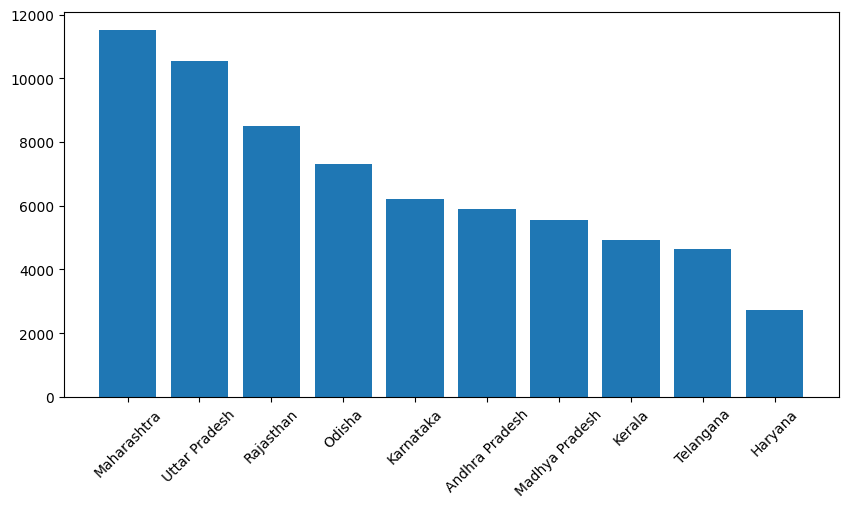

In [288]:
#sample plot
import matplotlib.pyplot as plt

top10 = final_df.sort_values(
    "Grievous_I",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["State"], top10["Grievous_I"])

plt.xticks(rotation=45)

plt.show()

In [289]:
cols = final_df.columns.drop("State")

final_df[cols] = final_df[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [290]:
doc[38].head(30)

,Unnamed: 0,Unnamed: 1,Offences affecting the Human Body
0,NaN,NaN,Assault on Women with Intent to Outrage her Mo...
1,NaN,NaN,Sexual Harassment
2,SL State/UT,NaN,NaN
3,NaN,NaN,Assault on Women (Sec. 354
4,NaN,NaN,IPC) Sexual Harassment (Sec.354A a) at Work or...
5,NaN,NaN,IPC) (Total)
6,NaN,NaN,I V R I V R I V R
7,[1] [2],NaN,[102] [103] [104] [105] [106] [107] [108] [109...
8,STATES:,NaN,NaN
9,1 Andhra Pradesh,NaN,3047 3192 11.5 1244 1265 4.7 37 37 0.1


In [291]:
df2=clean_table(doc[38])

In [292]:
df2 = df2.iloc[9:37]
df2 = df2.reset_index(drop=True)

print(df2.head())

            Unnamed: 0       Offences affecting the Human Body
0     1 Andhra Pradesh  3047 3192 11.5 1244 1265 4.7 37 37 0.1
1  2 Arunachal Pradesh               51 61 6.8 9 9 1.2 0 0 0.0
2              3 Assam       1210 1372 6.9 216 221 1.2 0 0 0.0
3              4 Bihar           333 334 0.6 14 14 0.0 0 0 0.0
4       5 Chhattisgarh       1065 1066 7.1 115 121 0.8 3 3 0.0


In [293]:
print(df2.iloc[0].to_string())

Unnamed: 0                                                 1 Andhra Pradesh
Offences affecting the Human Body    3047 3192 11.5 1244 1265 4.7 37 37 0.1


In [294]:


df2["State"] = df2["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)

print(df2[["State"]].head())

               State
0     Andhra Pradesh
1  Arunachal Pradesh
2              Assam
3              Bihar
4       Chhattisgarh


In [295]:
df2["Offences affecting the Human Body"].head()

0    3047 3192 11.5 1244 1265 4.7 37 37 0.1
1                 51 61 6.8 9 9 1.2 0 0 0.0
2         1210 1372 6.9 216 221 1.2 0 0 0.0
3             333 334 0.6 14 14 0.0 0 0 0.0
4         1065 1066 7.1 115 121 0.8 3 3 0.0
Name: Offences affecting the Human Body, dtype: object

In [296]:
final_df2 = pd.concat(
    [df2["State"], crime_cols],
    axis=1
)

print(final_df2.head())

cols = final_df2.columns.drop("State")

final_df2[cols] = final_df2[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

               State Assault_I Assault_V Assault_R Modesty_I Modesty_V  \
0     Andhra Pradesh         2         2       0.0      1800      1849   
1  Arunachal Pradesh         3         3       0.2         1         1   
2              Assam        94        94       0.3       148       162   
3              Bihar       281       283       0.2         0         0   
4       Chhattisgarh         3         3       0.0       109       109   

  Modesty_R Grievous_I Grievous_V Grievous_R  
0       3.4       5884       6118       22.2  
1       0.1         67         77        8.9  
2       0.4       1984       2168       11.4  
3       0.0        402        403        0.7  
4       0.4       1322       1329        8.9  


In [297]:
final_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State       28 non-null     object 
 1   Assault_I   28 non-null     int64  
 2   Assault_V   28 non-null     int64  
 3   Assault_R   28 non-null     float64
 4   Modesty_I   28 non-null     int64  
 5   Modesty_V   28 non-null     int64  
 6   Modesty_R   28 non-null     float64
 7   Grievous_I  28 non-null     int64  
 8   Grievous_V  28 non-null     int64  
 9   Grievous_R  28 non-null     float64
dtypes: float64(3), int64(6), object(1)
memory usage: 2.3+ KB


In [298]:
final_df2.isnull().sum()

State         0
Assault_I     0
Assault_V     0
Assault_R     0
Modesty_I     0
Modesty_V     0
Modesty_R     0
Grievous_I    0
Grievous_V    0
Grievous_R    0
dtype: int64

In [299]:
final_df2.describe()

,Assault_I,Assault_V,Assault_R,Modesty_I,Modesty_V,Modesty_R,Grievous_I,Grievous_V,Grievous_R
count,28.00000,28.00000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,25.50000,26.50000,0.042857,863.964286,900.714286,2.485714,2842.821429,2912.142857,11.442857
std,59.19741,60.69993,0.092009,2480.866582,2549.036199,8.243278,3432.543761,3500.970804,8.540857
min,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,9.000000,9.000000,0.700000
25%,0.00000,0.00000,0.000000,6.750000,7.500000,0.100000,87.000000,89.500000,4.525000
50%,1.50000,1.50000,0.000000,121.000000,124.500000,0.500000,1233.000000,1248.000000,9.150000
75%,19.25000,19.25000,0.000000,658.000000,672.500000,1.325000,5096.000000,5156.750000,18.800000
max,281.00000,283.00000,0.300000,13200.000000,13549.000000,44.000000,11512.000000,11611.000000,32.000000


In [300]:
final_df2.sort_values(
    "Grievous_I",
    ascending=False
)[["State","Grievous_I"]].head(38)

,State,Grievous_I
13,Maharashtra,11512
25,Uttar Pradesh,10548
20,Rajasthan,8508
18,Odisha,7327
10,Karnataka,6201
0,Andhra Pradesh,5884
12,Madhya Pradesh,5564
11,Kerala,4940
23,Telangana,4652
7,Haryana,2739


In [301]:
display(final_df2)

,State,Assault_I,Assault_V,Assault_R,Modesty_I,Modesty_V,Modesty_R,Grievous_I,Grievous_V,Grievous_R
0,Andhra Pradesh,2,2,0.0,1800,1849,3.4,5884,6118,22.2
1,Arunachal Pradesh,3,3,0.2,1,1,0.1,67,77,8.9
2,Assam,94,94,0.3,148,162,0.4,1984,2168,11.4
3,Bihar,281,283,0.2,0,0,0.0,402,403,0.7
4,Chhattisgarh,3,3,0.0,109,109,0.4,1322,1329,8.9
5,Goa,0,0,0.0,12,13,0.8,87,90,11.2
6,Gujarat,1,1,0.0,11,12,0.0,693,705,2.1
7,Haryana,0,0,0.0,13200,13549,44.0,2739,2742,19.4
8,Himachal Pradesh,0,0,0.0,437,437,5.9,492,494,13.4
9,Jharkhand,121,123,0.3,32,32,0.1,1144,1167,6.0


In [302]:
display(doc[45])

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Offences affecting the Human Body,Unnamed: 3
0,SL State/UT,NaN,Exploitation of Trafficked,Selling of Minors for,Buying of Minors for
1,NaN,NaN,Person (Sec. 370A IPC),Prostitution (Sec.372 IPC),Prostitution (Sec.373 IPC)
2,NaN,NaN,I V R,I V R,I V R
3,[1] [2],NaN,[165] [166] [167],[168] [169] [170],[171] [172] [173]
4,STATES:,NaN,NaN,NaN,NaN
5,1 Andhra Pradesh,NaN,32 50 0.1,0 0 0.0,0 0 0.0
6,2 Arunachal Pradesh,NaN,0 0 0.0,0 0 0.0,0 0 0.0
7,3 Assam,NaN,2 2 0.0,4 4 0.0,0 0 0.0
8,4 Bihar,NaN,0 0 0.0,0 0 0.0,0 0 0.0
9,5 Chhattisgarh,NaN,0 0 0.0,0 0 0.0,1 1 0.0


In [303]:
df3=clean_table(doc[45])

In [304]:
df3 = df3.iloc[0:46]
df3 = df3.reset_index(drop=True)

print(df3.head())

    Unnamed: 0                  Unnamed: 2 Offences affecting the Human Body  \
0  SL State/UT  Exploitation of Trafficked             Selling of Minors for   
1  SL State/UT      Person (Sec. 370A IPC)        Prostitution (Sec.372 IPC)   
2  SL State/UT                       I V R                             I V R   
3      [1] [2]           [165] [166] [167]                 [168] [169] [170]   
4      STATES:           [165] [166] [167]                 [168] [169] [170]   

                   Unnamed: 3  
0        Buying of Minors for  
1  Prostitution (Sec.373 IPC)  
2                       I V R  
3           [171] [172] [173]  
4           [171] [172] [173]  


In [305]:
print(df3.columns)

Index(['Unnamed: 0', 'Unnamed: 2', 'Offences affecting the Human Body',
       'Unnamed: 3'],
      dtype='object')


In [306]:
print(df3.iloc[5:20])

             Unnamed: 0 Unnamed: 2 Offences affecting the Human Body  \
5      1 Andhra Pradesh  32 50 0.1                           0 0 0.0   
6   2 Arunachal Pradesh    0 0 0.0                           0 0 0.0   
7               3 Assam    2 2 0.0                           4 4 0.0   
8               4 Bihar    0 0 0.0                           0 0 0.0   
9        5 Chhattisgarh    0 0 0.0                           0 0 0.0   
10                6 Goa    4 7 0.3                           0 0 0.0   
11            7 Gujarat    1 1 0.0                           0 0 0.0   
12            8 Haryana    4 4 0.0                           0 0 0.0   
13   9 Himachal Pradesh    0 0 0.0                           0 0 0.0   
14         10 Jharkhand    1 5 0.0                           1 1 0.0   
15         11 Karnataka    1 1 0.0                           0 0 0.0   
16            12 Kerala    1 1 0.0                           0 0 0.0   
17    13 Madhya Pradesh    4 9 0.0                           1 3

In [307]:
df3 = df3.iloc[5:]
df3 = df3.reset_index(drop=True)

In [308]:
df3["State"] = df3["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)

In [309]:
df3["Crime_Data"] = (
    df3["Unnamed: 2"].astype(str) + " " +
    df3["Offences affecting the Human Body"].astype(str) + " " +
    df3["Unnamed: 3"].astype(str)
)

In [310]:
crime_cols = df3["Crime_Data"].str.split(
    expand=True
)

In [311]:
print(crime_cols.head())

    0   1    2  3  4    5  6  7    8
0  32  50  0.1  0  0  0.0  0  0  0.0
1   0   0  0.0  0  0  0.0  0  0  0.0
2   2   2  0.0  4  4  0.0  0  0  0.0
3   0   0  0.0  0  0  0.0  0  0  0.0
4   0   0  0.0  0  0  0.0  1  1  0.0


In [312]:
crime_cols.columns = [
    "Trafficked_I",
    "Trafficked_V",
    "Trafficked_R",
    "Selling_I",
    "Selling_V",
    "Selling_R",
    "Buying_I",
    "Buying_V",
    "Buying_R"
]

In [313]:
final_df3 = pd.concat(
    [df3["State"], crime_cols],
    axis=1
)

In [314]:
cols = final_df3.columns.drop("State")

final_df3[cols] = final_df3[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [315]:
final_df3.head()

,State,Trafficked_I,Trafficked_V,Trafficked_R,Selling_I,Selling_V,Selling_R,Buying_I,Buying_V,Buying_R
0,Andhra Pradesh,32,50,0.1,0,0,0.0,0,0,0.0
1,Arunachal Pradesh,0,0,0.0,0,0,0.0,0,0,0.0
2,Assam,2,2,0.0,4,4,0.0,0,0,0.0
3,Bihar,0,0,0.0,0,0,0.0,0,0,0.0
4,Chhattisgarh,0,0,0.0,0,0,0.0,1,1,0.0


In [316]:
final_df3

,State,Trafficked_I,Trafficked_V,Trafficked_R,Selling_I,Selling_V,Selling_R,Buying_I,Buying_V,Buying_R
0,Andhra Pradesh,32,50,0.1,0,0,0.0,0,0,0.0
1,Arunachal Pradesh,0,0,0.0,0,0,0.0,0,0,0.0
2,Assam,2,2,0.0,4,4,0.0,0,0,0.0
3,Bihar,0,0,0.0,0,0,0.0,0,0,0.0
4,Chhattisgarh,0,0,0.0,0,0,0.0,1,1,0.0
5,Goa,4,7,0.3,0,0,0.0,0,0,0.0
6,Gujarat,1,1,0.0,0,0,0.0,0,0,0.0
7,Haryana,4,4,0.0,0,0,0.0,0,0,0.0
8,Himachal Pradesh,0,0,0.0,0,0,0.0,0,0,0.0
9,Jharkhand,1,5,0.0,1,1,0.0,0,0,0.0


In [317]:
doc[46]

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Offences affecting the Human Body,Unnamed: 3
0,NaN,NaN,NaN,Unnatural,NaN
1,SL State/UT,NaN,Rape (Sec.376 IPC),Attempt to Commit Offences (Sec.377,Offences Affecting the
2,NaN,NaN,NaN,Rape (Sec.376/511 IPC),Human Body (Total)
3,NaN,NaN,NaN,IPC),NaN
4,NaN,NaN,I V R,I V R I V R,I V R
5,[1] [2],NaN,[174] [175] [176],[177] [178] [179] [180] [181] [182],[183] [184] [185]
6,STATES:,NaN,NaN,NaN,NaN
7,1 Andhra Pradesh,NaN,621 627 2.3,180 180 0.7 8 8 0.0,49265 53951 92.9
8,2 Arunachal Pradesh,NaN,74 74 9.8,3 3 0.4 0 0 0.0,685 790 44.2
9,3 Assam,NaN,1113 1478 6.4,253 283 1.5 0 0 0.0,21252 24271 59.9


In [318]:
df4 = doc[46]          # whatever table number this is

df4 = df4.iloc[7:48]
df4 = df4.reset_index(drop=True)

In [319]:
df4 = df4[
    ~df4["Unnamed: 0"].astype(str).str.contains(
        "TOTAL|UNION",
        na=False
    )
]

In [320]:
df4 = df4[
    df4["Unnamed: 0"].astype(str).str.match(
        r"^\d+",
        na=False
    )
]

In [321]:
df4["State"] = df4["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)

In [322]:
df4["Crime_Data"] = (
    df4["Unnamed: 2"].fillna("").astype(str)
    + " "
    + df4["Offences affecting the Human Body"].fillna("").astype(str)
    + " "
    + df4["Unnamed: 3"].fillna("").astype(str)
)

In [323]:
crime_cols = df4["Crime_Data"].str.split(
    expand=True
)

In [324]:
print(crime_cols.shape)

(36, 12)


In [325]:
crime_cols.columns = [
    "Rape_I",
    "Rape_V",
    "Rape_R",

    "Attempt_I",
    "Attempt_V",
    "Attempt_R",

    "Unnatural_I",
    "Unnatural_V",
    "Unnatural_R",

    "Total_I",
    "Total_V",
    "Total_R"
]

In [326]:
final_df4 = pd.concat(
    [df4["State"], crime_cols],
    axis=1
)

In [327]:
cols = final_df4.columns.drop("State")

final_df4[cols] = final_df4[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [328]:
final_df4.head()

,State,Rape_I,Rape_V,Rape_R,Attempt_I,Attempt_V,Attempt_R,Unnatural_I,Unnatural_V,Unnatural_R,Total_I,Total_V,Total_R
0,Andhra Pradesh,621,627,2.3,180,180,0.7,8,8,0.0,49265,53951,92.9
1,Arunachal Pradesh,74,74,9.8,3,3,0.4,0,0,0.0,685,790,44.2
2,Assam,1113,1478,6.4,253,283,1.5,0,0,0.0,21252,24271,59.9
3,Bihar,881,881,1.5,17,17,0.0,4,4,0.0,138517,157923,110.3
4,Chhattisgarh,1246,1246,8.3,8,8,0.1,10,10,0.0,39303,40458,131.2


In [329]:
final_df4

,State,Rape_I,Rape_V,Rape_R,Attempt_I,Attempt_V,Attempt_R,Unnatural_I,Unnatural_V,Unnatural_R,Total_I,Total_V,Total_R
0,Andhra Pradesh,621,627,2.3,180,180,0.7,8,8,0.0,49265,53951,92.9
1,Arunachal Pradesh,74,74,9.8,3,3,0.4,0,0,0.0,685,790,44.2
2,Assam,1113,1478,6.4,253,283,1.5,0,0,0.0,21252,24271,59.9
3,Bihar,881,881,1.5,17,17,0.0,4,4,0.0,138517,157923,110.3
4,Chhattisgarh,1246,1246,8.3,8,8,0.1,10,10,0.0,39303,40458,131.2
5,Goa,73,75,9.4,0,0,0.0,1,1,0.1,827,1004,52.7
6,Gujarat,610,610,1.8,2,2,0.0,22,20,0.0,20596,22919,29.0
7,Haryana,1787,1787,12.7,255,255,1.8,104,104,0.3,36219,37467,120.9
8,Himachal Pradesh,359,369,9.8,9,9,0.2,13,13,0.2,5957,6285,80.0
9,Jharkhand,1298,1298,6.8,88,88,0.5,3,3,0.0,23185,24077,59.2


In [330]:
doc[47]

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Offences against State,Unnamed: 3
0,SL State/UT,NaN,Sedition (Sec.124A IPC),"Others (Sec.121, 121A, 122 &",Offences against the State
1,NaN,NaN,NaN,123 IPC),(Total)
2,NaN,NaN,I V R,I V R,I V R
3,[1] [2],NaN,[186] [187] [188],[189] [190] [191],[192] [193] [194]
4,STATES:,NaN,NaN,NaN,NaN
5,1 Andhra Pradesh,NaN,0 0 0.0,12 12 0.0,12 12 0.0
6,2 Arunachal Pradesh,NaN,0 0 0.0,0 0 0.0,0 0 0.0
7,3 Assam,NaN,0 0 0.0,4 4 0.0,4 4 0.0
8,4 Bihar,NaN,0 0 0.0,0 0 0.0,0 0 0.0
9,5 Chhattisgarh,NaN,1 1 0.0,0 0 0.0,1 1 0.0


In [331]:
df5 = doc[47]

df5 = df5.iloc[5:46]
df5 = df5.reset_index(drop=True)

In [332]:
df5["State"] = df5["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)

In [333]:
df5["Crime_Data"] = (
    df5["Unnamed: 2"].astype(str)
    + " "
    + df5["Offences against State"].astype(str)
    + " "
    + df5["Unnamed: 3"].astype(str)
)

In [334]:
df = df[
    ~df["Unnamed: 0"].astype(str).str.contains(
        "TOTAL|UNION|STATES",
        na=False
    )
]

In [335]:
crime_cols = df5["Crime_Data"].str.split(
    expand=True
)

In [336]:
crime_cols.columns = [
    "Sedition_I",
    "Sedition_V",
    "Sedition_R",

    "Others_I",
    "Others_V",
    "Others_R",

    "Total_I",
    "Total_V",
    "Total_R"
]

In [337]:
final_df5 = pd.concat(
    [df5["State"], crime_cols],
    axis=1
)

In [338]:
cols = final_df5.columns.drop("State")

final_df5[cols] = final_df5[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [339]:
final_df5

,State,Sedition_I,Sedition_V,Sedition_R,Others_I,Others_V,Others_R,Total_I,Total_V,Total_R
0,Andhra Pradesh,0.0,0.0,0.0,12.0,12.0,0.0,12.0,12.0,0.0
1,Arunachal Pradesh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Assam,0.0,0.0,0.0,4.0,4.0,0.0,4.0,4.0,0.0
3,Bihar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Chhattisgarh,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5,Goa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Gujarat,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
7,Haryana,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
8,Himachal Pradesh,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
9,Jharkhand,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [340]:
final_df5_states = final_df5.iloc[:28]

In [341]:
final_df5_states

,State,Sedition_I,Sedition_V,Sedition_R,Others_I,Others_V,Others_R,Total_I,Total_V,Total_R
0,Andhra Pradesh,0.0,0.0,0.0,12.0,12.0,0.0,12.0,12.0,0.0
1,Arunachal Pradesh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Assam,0.0,0.0,0.0,4.0,4.0,0.0,4.0,4.0,0.0
3,Bihar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Chhattisgarh,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5,Goa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Gujarat,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
7,Haryana,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
8,Himachal Pradesh,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
9,Jharkhand,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [342]:
doc[56]

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Offences against Property,Unnamed: 3
0,NaN,NaN,Theft (Section 379 IPC),Burglary (Sec.454 to 460 r/w Sec.380 IPC),NaN
1,SL State/UT,NaN,NaN,NaN,NaN
2,NaN,NaN,B) Other Thefts,Burglary (Total) A) Day Time,NaN
3,NaN,NaN,I V R,I V R I V,R
4,[1] [2],NaN,[269] [270] [271],[272] [273] [274] [275] [276],[277]
5,STATES:,NaN,NaN,NaN,NaN
6,1 Andhra Pradesh,NaN,8213 8612 15.5,4086 4375 7.7 751 825,1.4
7,2 Arunachal Pradesh,NaN,407 409 26.2,168 178 10.8 40 40,2.6
8,3 Assam,NaN,7099 8438 20.0,3121 4020 8.8 509 666,1.4
9,4 Bihar,NaN,14845 14846 11.8,4161 4166 3.3 23 23,0.0


In [343]:
df6=doc[56]
df6=df6.iloc[6:47]
df6=df6.reset_index(drop=True)

In [344]:
df6["State"] = df6["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)

In [345]:
print(df6.columns)

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Offences against Property',
       'Unnamed: 3', 'State'],
      dtype='object')


In [346]:
print(df6["Unnamed: 2"].head())

0      8213 8612 15.5
1        407 409 26.2
2      7099 8438 20.0
3    14845 14846 11.8
4      4409 4590 14.7
Name: Unnamed: 2, dtype: object


In [347]:
print(df6['Offences against Property'].head())

0     4086 4375 7.7 751 825
1        168 178 10.8 40 40
2     3121 4020 8.8 509 666
3       4161 4166 3.3 23 23
4    4253 4271 14.2 410 410
Name: Offences against Property, dtype: object


In [348]:
temp=df6["Offences against Property"].str.split(expand=True)
print(temp.head())

      0     1     2    3    4
0  4086  4375   7.7  751  825
1   168   178  10.8   40   40
2  3121  4020   8.8  509  666
3  4161  4166   3.3   23   23
4  4253  4271  14.2  410  410


In [349]:
print(df6["Unnamed: 3"].head())

0    1.4
1    2.6
2    1.4
3    0.0
4    1.4
Name: Unnamed: 3, dtype: object


In [350]:
temp.columns = [
    "Burglary_Total_I",
    "Burglary_Total_V",
    "Burglary_Total_R",
    "Burglary_Day_I",
    "Burglary_Day_V"
]
temp["Burglary_Day_R"] = df6["Unnamed: 3"]

In [351]:
print(temp.head())

  Burglary_Total_I Burglary_Total_V Burglary_Total_R Burglary_Day_I  \
0             4086             4375              7.7            751   
1              168              178             10.8             40   
2             3121             4020              8.8            509   
3             4161             4166              3.3             23   
4             4253             4271             14.2            410   

  Burglary_Day_V Burglary_Day_R  
0            825            1.4  
1             40            2.6  
2            666            1.4  
3             23            0.0  
4            410            1.4  


In [352]:
print(df6["State"].head())

0       Andhra Pradesh
1    Arunachal Pradesh
2                Assam
3                Bihar
4         Chhattisgarh
Name: State, dtype: object


In [353]:
final_df6=pd.concat([df6["State"],temp],axis=1)

In [354]:
final_df6

,State,Burglary_Total_I,Burglary_Total_V,Burglary_Total_R,Burglary_Day_I,Burglary_Day_V,Burglary_Day_R
0,Andhra Pradesh,4086,4375,7.7,751,825,1.4
1,Arunachal Pradesh,168,178,10.8,40,40,2.6
2,Assam,3121,4020,8.8,509,666,1.4
3,Bihar,4161,4166,3.3,23,23,0.0
4,Chhattisgarh,4253,4271,14.2,410,410,1.4
5,Goa,103,104,6.6,25,26,1.6
6,Gujarat,3295,3313,4.6,359,360,0.5
7,Haryana,9242,9261,30.8,1591,1594,5.3
8,Himachal Pradesh,492,502,6.6,140,140,1.9
9,Jharkhand,1994,1995,5.1,69,69,0.2


In [355]:
crime_cols=final_df6.columns.drop("State")
final_df6=final_df6.dropna(subset=crime_cols,how="all")

In [356]:
final_df6

,State,Burglary_Total_I,Burglary_Total_V,Burglary_Total_R,Burglary_Day_I,Burglary_Day_V,Burglary_Day_R
0,Andhra Pradesh,4086,4375,7.7,751,825,1.4
1,Arunachal Pradesh,168,178,10.8,40,40,2.6
2,Assam,3121,4020,8.8,509,666,1.4
3,Bihar,4161,4166,3.3,23,23,0.0
4,Chhattisgarh,4253,4271,14.2,410,410,1.4
5,Goa,103,104,6.6,25,26,1.6
6,Gujarat,3295,3313,4.6,359,360,0.5
7,Haryana,9242,9261,30.8,1591,1594,5.3
8,Himachal Pradesh,492,502,6.6,140,140,1.9
9,Jharkhand,1994,1995,5.1,69,69,0.2


In [357]:
cols = final_df6.columns.drop("State")

final_df6[cols] = final_df6[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

C:\Users\Bhumika\AppData\Local\Temp\ipykernel_4280\515149642.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df6[cols] = final_df6[cols].apply(


In [358]:
final_df6

doc[57]

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Offences against Property,Unnamed: 3
0,NaN,NaN,Burglary (Sec.454 to 460 r/w,NaN,NaN
1,NaN,NaN,Sec.380 IPC),NaN,NaN
2,SL State/UT,NaN,NaN,Extortion & Blackmailing,Robbery (Sec.392/394/397 IPC)
3,NaN,NaN,B) Night,(Sec.384 to 389 IPC),NaN
4,NaN,NaN,I V R,I V R,I V R
5,[1] [2],NaN,[278] [279] [280],[281] [282] [283],[284] [285] [286]
6,STATES:,NaN,NaN,NaN,NaN
7,1 Andhra Pradesh,NaN,3335 3550 6.3,415 424 0.8,294 299 0.6
8,2 Arunachal Pradesh,NaN,128 138 8.3,45 45 2.9,52 53 3.4
9,3 Assam,NaN,2612 3354 7.4,605 746 1.7,705 868 2.0


In [359]:
df7=doc[57]
df7=df7.iloc[7:48]
df7=df7.reset_index(drop=True)

In [360]:
df7

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Offences against Property,Unnamed: 3
0,1 Andhra Pradesh,NaN,3335 3550 6.3,415 424 0.8,294 299 0.6
1,2 Arunachal Pradesh,NaN,128 138 8.3,45 45 2.9,52 53 3.4
2,3 Assam,NaN,2612 3354 7.4,605 746 1.7,705 868 2.0
3,4 Bihar,NaN,4138 4143 3.3,666 670 0.5,2282 2284 1.8
4,5 Chhattisgarh,NaN,3843 3861 12.8,74 74 0.2,495 502 1.7
5,6 Goa,NaN,78 78 5.0,12 12 0.8,14 14 0.9
6,7 Gujarat,NaN,2936 2953 4.1,274 277 0.4,575 590 0.8
7,8 Haryana,NaN,7651 7667 25.5,518 519 1.7,617 622 2.1
8,9 Himachal Pradesh,NaN,352 362 4.7,10 10 0.1,8 8 0.1
9,10 Jharkhand,NaN,1925 1926 4.9,594 597 1.5,702 703 1.8


In [361]:
df7=df7.drop(columns=["Unnamed: 1"])

In [362]:
df7 = df7.rename(
    columns={
        "Unnamed: 0": "State"
    }
)

In [363]:
df7

,State,Unnamed: 2,Offences against Property,Unnamed: 3
0,1 Andhra Pradesh,3335 3550 6.3,415 424 0.8,294 299 0.6
1,2 Arunachal Pradesh,128 138 8.3,45 45 2.9,52 53 3.4
2,3 Assam,2612 3354 7.4,605 746 1.7,705 868 2.0
3,4 Bihar,4138 4143 3.3,666 670 0.5,2282 2284 1.8
4,5 Chhattisgarh,3843 3861 12.8,74 74 0.2,495 502 1.7
5,6 Goa,78 78 5.0,12 12 0.8,14 14 0.9
6,7 Gujarat,2936 2953 4.1,274 277 0.4,575 590 0.8
7,8 Haryana,7651 7667 25.5,518 519 1.7,617 622 2.1
8,9 Himachal Pradesh,352 362 4.7,10 10 0.1,8 8 0.1
9,10 Jharkhand,1925 1926 4.9,594 597 1.5,702 703 1.8


In [364]:
df7["State"] = df7["State"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)

In [365]:
df7

,State,Unnamed: 2,Offences against Property,Unnamed: 3
0,Andhra Pradesh,3335 3550 6.3,415 424 0.8,294 299 0.6
1,Arunachal Pradesh,128 138 8.3,45 45 2.9,52 53 3.4
2,Assam,2612 3354 7.4,605 746 1.7,705 868 2.0
3,Bihar,4138 4143 3.3,666 670 0.5,2282 2284 1.8
4,Chhattisgarh,3843 3861 12.8,74 74 0.2,495 502 1.7
5,Goa,78 78 5.0,12 12 0.8,14 14 0.9
6,Gujarat,2936 2953 4.1,274 277 0.4,575 590 0.8
7,Haryana,7651 7667 25.5,518 519 1.7,617 622 2.1
8,Himachal Pradesh,352 362 4.7,10 10 0.1,8 8 0.1
9,Jharkhand,1925 1926 4.9,594 597 1.5,702 703 1.8


In [366]:
temp1 = df7["Unnamed: 2"].str.split(expand=True)

temp2 = df7["Offences against Property"].str.split(
    expand=True
)

temp3 = df7["Unnamed: 3"].str.split(expand=True)

In [367]:
temp1.columns = [
    "Burglary_Night_I",
    "Burglary_Night_V",
    "Burglary_Night_R"
]

temp2.columns = [
    "Extortion_I",
    "Extortion_V",
    "Extortion_R"
]

temp3.columns = [
    "Robbery_I",
    "Robbery_V",
    "Robbery_R"
]

In [368]:
final_df7 = pd.concat(
    [
        df7["State"],
        temp1,
        temp2,
        temp3
    ],
    axis=1
)

In [369]:
final_df7

,State,Burglary_Night_I,Burglary_Night_V,Burglary_Night_R,Extortion_I,Extortion_V,Extortion_R,Robbery_I,Robbery_V,Robbery_R
0,Andhra Pradesh,3335,3550,6.3,415,424,0.8,294,299,0.6
1,Arunachal Pradesh,128,138,8.3,45,45,2.9,52,53,3.4
2,Assam,2612,3354,7.4,605,746,1.7,705,868,2.0
3,Bihar,4138,4143,3.3,666,670,0.5,2282,2284,1.8
4,Chhattisgarh,3843,3861,12.8,74,74,0.2,495,502,1.7
5,Goa,78,78,5.0,12,12,0.8,14,14,0.9
6,Gujarat,2936,2953,4.1,274,277,0.4,575,590,0.8
7,Haryana,7651,7667,25.5,518,519,1.7,617,622,2.1
8,Himachal Pradesh,352,362,4.7,10,10,0.1,8,8,0.1
9,Jharkhand,1925,1926,4.9,594,597,1.5,702,703,1.8


In [378]:
doc[69]

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Miscellaneous IPC Crimes,Unnamed: 3
0,SL State/UT,NaN,Obscene Acts and Songs at,Offences relating to Religion,Cheating by Impersonation
1,NaN,NaN,Public Places (Sec.294),(Sec.295 to 297),(Sec.419 IPC)
2,NaN,NaN,I V R,I V R,I V R
3,[1] [2],NaN,[386] [387] [388],[389] [390] [391],[392] [393] [394]
4,STATES:,NaN,NaN,NaN,NaN
5,1 Andhra Pradesh,NaN,648 657 1.2,25 25 0.0,278 278 0.5
6,2 Arunachal Pradesh,NaN,0 0 0.0,0 0 0.0,7 7 0.5
7,3 Assam,NaN,343 343 1.0,12 12 0.0,50 50 0.1
8,4 Bihar,NaN,0 0 0.0,2 2 0.0,2 2 0.0
9,5 Chhattisgarh,NaN,557 579 1.9,105 105 0.4,12 12 0.0


In [379]:
df8=doc[69]
df8=df8.iloc[5:46]
df8=df8.reset_index(drop=True)


In [380]:
df8

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Miscellaneous IPC Crimes,Unnamed: 3
0,1 Andhra Pradesh,NaN,648 657 1.2,25 25 0.0,278 278 0.5
1,2 Arunachal Pradesh,NaN,0 0 0.0,0 0 0.0,7 7 0.5
2,3 Assam,NaN,343 343 1.0,12 12 0.0,50 50 0.1
3,4 Bihar,NaN,0 0 0.0,2 2 0.0,2 2 0.0
4,5 Chhattisgarh,NaN,557 579 1.9,105 105 0.4,12 12 0.0
5,6 Goa,NaN,0 0 0.0,7 7 0.4,0 0 0.0
6,7 Gujarat,NaN,53 54 0.1,20 19 0.0,2 2 0.0
7,8 Haryana,NaN,232 234 0.8,95 95 0.3,1 1 0.0
8,9 Himachal Pradesh,NaN,0 0 0.0,16 16 0.2,0 0 0.0
9,10 Jharkhand,NaN,0 0 0.0,43 48 0.1,2 2 0.0


In [381]:
df8=df8.drop(columns=["Unnamed: 1"])

In [382]:
df8

,Unnamed: 0,Unnamed: 2,Miscellaneous IPC Crimes,Unnamed: 3
0,1 Andhra Pradesh,648 657 1.2,25 25 0.0,278 278 0.5
1,2 Arunachal Pradesh,0 0 0.0,0 0 0.0,7 7 0.5
2,3 Assam,343 343 1.0,12 12 0.0,50 50 0.1
3,4 Bihar,0 0 0.0,2 2 0.0,2 2 0.0
4,5 Chhattisgarh,557 579 1.9,105 105 0.4,12 12 0.0
5,6 Goa,0 0 0.0,7 7 0.4,0 0 0.0
6,7 Gujarat,53 54 0.1,20 19 0.0,2 2 0.0
7,8 Haryana,232 234 0.8,95 95 0.3,1 1 0.0
8,9 Himachal Pradesh,0 0 0.0,16 16 0.2,0 0 0.0
9,10 Jharkhand,0 0 0.0,43 48 0.1,2 2 0.0


In [384]:
df8["State"] = df8["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)
df8["State"].head()

0       Andhra Pradesh
1    Arunachal Pradesh
2                Assam
3                Bihar
4         Chhattisgarh
Name: State, dtype: object

In [385]:
temp1=df8["Unnamed: 2"].str.split(expand=True)
temp1.columns=["ObsceneActs_I","ObsceneActs_V","ObsceneActs_R"]

temp2=df8["Unnamed: 3"].str.split(expand=True)
temp2.columns=["CheatingImpersonation_I","CheatingImpersonation_V","CheatingImpersonation_R"]

temp3=df8["Miscellaneous IPC Crimes"].str.split(expand=True)
temp3.columns=["Religion_I","Religion_V","Religion_R"]

In [388]:
final_df8=pd.concat([df8["State"],temp1,temp3,temp2],axis=1)

In [389]:
cols = final_df8.columns.drop("State")

final_df8.loc[:, cols] = final_df8.loc[:, cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [390]:
final_df8

,State,ObsceneActs_I,ObsceneActs_V,ObsceneActs_R,Religion_I,Religion_V,Religion_R,CheatingImpersonation_I,CheatingImpersonation_V,CheatingImpersonation_R
0,Andhra Pradesh,648.0,657.0,1.2,25.0,25.0,0.0,278.0,278.0,0.5
1,Arunachal Pradesh,0.0,0.0,0.0,0.0,0.0,0.0,7.0,7.0,0.5
2,Assam,343.0,343.0,1.0,12.0,12.0,0.0,50.0,50.0,0.1
3,Bihar,0.0,0.0,0.0,2.0,2.0,0.0,2.0,2.0,0.0
4,Chhattisgarh,557.0,579.0,1.9,105.0,105.0,0.4,12.0,12.0,0.0
5,Goa,0.0,0.0,0.0,7.0,7.0,0.4,0.0,0.0,0.0
6,Gujarat,53.0,54.0,0.1,20.0,19.0,0.0,2.0,2.0,0.0
7,Haryana,232.0,234.0,0.8,95.0,95.0,0.3,1.0,1.0,0.0
8,Himachal Pradesh,0.0,0.0,0.0,16.0,16.0,0.2,0.0,0.0,0.0
9,Jharkhand,0.0,0.0,0.0,43.0,48.0,0.1,2.0,2.0,0.0


In [391]:
crime_cols=final_df8.columns.drop("State")
final_df8=final_df8.dropna(subset=crime_cols,how="all")

In [392]:
final_df8

,State,ObsceneActs_I,ObsceneActs_V,ObsceneActs_R,Religion_I,Religion_V,Religion_R,CheatingImpersonation_I,CheatingImpersonation_V,CheatingImpersonation_R
0,Andhra Pradesh,648.0,657.0,1.2,25.0,25.0,0.0,278.0,278.0,0.5
1,Arunachal Pradesh,0.0,0.0,0.0,0.0,0.0,0.0,7.0,7.0,0.5
2,Assam,343.0,343.0,1.0,12.0,12.0,0.0,50.0,50.0,0.1
3,Bihar,0.0,0.0,0.0,2.0,2.0,0.0,2.0,2.0,0.0
4,Chhattisgarh,557.0,579.0,1.9,105.0,105.0,0.4,12.0,12.0,0.0
5,Goa,0.0,0.0,0.0,7.0,7.0,0.4,0.0,0.0,0.0
6,Gujarat,53.0,54.0,0.1,20.0,19.0,0.0,2.0,2.0,0.0
7,Haryana,232.0,234.0,0.8,95.0,95.0,0.3,1.0,1.0,0.0
8,Himachal Pradesh,0.0,0.0,0.0,16.0,16.0,0.2,0.0,0.0,0.0
9,Jharkhand,0.0,0.0,0.0,43.0,48.0,0.1,2.0,2.0,0.0


In [396]:
doc[73]

,Unnamed: 0,Unnamed: 1,Crime Against Women - Related Acts
0,NaN,NaN,The Protection of Women
1,SL State/UT,NaN,"The Dowry Prohibition Act, The Immoral Traffic..."
2,NaN,NaN,"1961 Prevention Act, 1956"
3,NaN,NaN,2005
4,NaN,NaN,I V R I V R I V R
5,[1] [2],NaN,[3] [4] [5] [6] [7] [8] [9] [10] [11]
6,STATES:,NaN,NaN
7,1 Andhra Pradesh,NaN,298 298 1.1 95 120 0.4 0 0 0.0
8,2 Arunachal Pradesh,NaN,0 0 0.0 0 0 0.0 1 1 0.1
9,3 Assam,NaN,272 288 1.6 29 47 0.2 0 0 0.0


In [402]:
df9=doc[73]
df9=df9.iloc[7:48]
df9=df9.reset_index(drop=True)
df9=df9.drop(columns=["Unnamed: 1"])

In [403]:
df9["State"] = df9["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)
df9["State"].head()

0       Andhra Pradesh
1    Arunachal Pradesh
2                Assam
3                Bihar
4         Chhattisgarh
Name: State, dtype: object

In [401]:
df9

,Unnamed: 0,Crime Against Women - Related Acts,State
0,1 Andhra Pradesh,298 298 1.1 95 120 0.4 0 0 0.0,Andhra Pradesh
1,2 Arunachal Pradesh,0 0 0.0 0 0 0.0 1 1 0.1,Arunachal Pradesh
2,3 Assam,272 288 1.6 29 47 0.2 0 0 0.0,Assam
3,4 Bihar,3580 3580 5.9 74 109 0.1 0 0 0.0,Bihar
4,5 Chhattisgarh,9 9 0.1 5 5 0.0 0 0 0.0,Chhattisgarh
5,6 Goa,0 0 0.0 0 0 0.0 0 0 0.0,Goa
6,7 Gujarat,1 1 0.0 122 132 0.4 1 1 0.0,Gujarat
7,8 Haryana,17 17 0.1 58 66 0.4 1 1 0.0,Haryana
8,9 Himachal Pradesh,1 1 0.0 5 7 0.1 2 2 0.1,Himachal Pradesh
9,10 Jharkhand,1796 1844 9.4 10 10 0.1 67 67 0.4,Jharkhand


In [406]:
temp = df9["Crime Against Women - Related Acts"].str.split(expand=True)
temp.head()
temp.shape

(41, 9)

In [407]:
temp.columns = [
    "ProtectionWomen_I",
    "ProtectionWomen_V",
    "ProtectionWomen_R",

    "DowryAct_I",
    "DowryAct_V",
    "DowryAct_R",

    "ImmoralTraffic_I",
    "ImmoralTraffic_V",
    "ImmoralTraffic_R"
]

In [408]:
final_df9=pd.concat([df9["State"],temp],axis=1)

In [410]:
cols = final_df9.columns.drop("State")

final_df9.loc[:, cols] = final_df9.loc[:, cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [411]:
final_df9

,State,ProtectionWomen_I,ProtectionWomen_V,ProtectionWomen_R,DowryAct_I,DowryAct_V,DowryAct_R,ImmoralTraffic_I,ImmoralTraffic_V,ImmoralTraffic_R
0,Andhra Pradesh,298.0,298.0,1.1,95.0,120.0,0.4,0.0,0.0,0.0
1,Arunachal Pradesh,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.1
2,Assam,272.0,288.0,1.6,29.0,47.0,0.2,0.0,0.0,0.0
3,Bihar,3580.0,3580.0,5.9,74.0,109.0,0.1,0.0,0.0,0.0
4,Chhattisgarh,9.0,9.0,0.1,5.0,5.0,0.0,0.0,0.0,0.0
5,Goa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Gujarat,1.0,1.0,0.0,122.0,132.0,0.4,1.0,1.0,0.0
7,Haryana,17.0,17.0,0.1,58.0,66.0,0.4,1.0,1.0,0.0
8,Himachal Pradesh,1.0,1.0,0.0,5.0,7.0,0.1,2.0,2.0,0.1
9,Jharkhand,1796.0,1844.0,9.4,10.0,10.0,0.1,67.0,67.0,0.4


In [413]:
crime_cols=final_df9.columns.drop("State")
final_df9=final_df9.dropna(subset=crime_cols,how="all")
final_df9=final_df9.drop(33)

In [414]:
final_df9

,State,ProtectionWomen_I,ProtectionWomen_V,ProtectionWomen_R,DowryAct_I,DowryAct_V,DowryAct_R,ImmoralTraffic_I,ImmoralTraffic_V,ImmoralTraffic_R
0,Andhra Pradesh,298.0,298.0,1.1,95.0,120.0,0.4,0.0,0.0,0.0
1,Arunachal Pradesh,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.1
2,Assam,272.0,288.0,1.6,29.0,47.0,0.2,0.0,0.0,0.0
3,Bihar,3580.0,3580.0,5.9,74.0,109.0,0.1,0.0,0.0,0.0
4,Chhattisgarh,9.0,9.0,0.1,5.0,5.0,0.0,0.0,0.0,0.0
5,Goa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Gujarat,1.0,1.0,0.0,122.0,132.0,0.4,1.0,1.0,0.0
7,Haryana,17.0,17.0,0.1,58.0,66.0,0.4,1.0,1.0,0.0
8,Himachal Pradesh,1.0,1.0,0.0,5.0,7.0,0.1,2.0,2.0,0.1
9,Jharkhand,1796.0,1844.0,9.4,10.0,10.0,0.1,67.0,67.0,0.4


In [415]:
doc[74]

,Unnamed: 0,Unnamed: 1,Crime Against Women - Related Acts,Children Related - Acts
0,NaN,NaN,The Indecent,The Protection of Children
1,SL State/UT,NaN,Crime Against Women  Representation of Women,"from Sexual Offences Act,"
2,NaN,NaN,Related Acts (Total),NaN
3,NaN,NaN,"Prohibition Act, 2012",2012
4,NaN,NaN,I V R I V R,I V R
5,[1] [2],NaN,[12] [13] [14] [15] [16] [17],[18] [19] [20]
6,STATES:,NaN,NaN,NaN
7,1 Andhra Pradesh,NaN,1 2 0.0 394 420 1.5,2136 2358 14.1
8,2 Arunachal Pradesh,NaN,0 0 0.0 1 1 0.1,47 58 8.0
9,3 Assam,NaN,0 0 0.0 301 335 1.7,1703 1804 14.1


In [416]:
df10=doc[74]
df10=df10.iloc[7:48]
df10=df10.reset_index(drop=True)
df10=df10.drop(columns=["Unnamed: 1"])

In [417]:
df10["State"] = df10["Unnamed: 0"].str.replace(
    r"^\d+\s+",
    "",
    regex=True
)
df10["State"].head()

0       Andhra Pradesh
1    Arunachal Pradesh
2                Assam
3                Bihar
4         Chhattisgarh
Name: State, dtype: object

In [422]:
temp1=df10["Crime Against Women - Related Acts"].str.split(expand=True)
temp1.columns=[
    "Indecent Crime Against Women_I",
    "Indecent Crime Against Women_V",
    "Indecent Crime Against Women_R",

    "Prohibition Act 2012_I",
    "Prohibition Act 2012_V",
    "Prohibition Act 2012_R"]

temp2=df10["Children Related - Acts"].str.split(expand=True)
temp2.columns=[
    "Protection Of Children From Sexual Offences_I",
    "Protection Of Children From Sexual Offences_V",
    "Protection Of Children From Sexual Offences_R"]

final_df10=pd.concat([df10["State"],temp1,temp2],axis=1)
    

In [423]:
final_df10

,State,Indecent Crime Against Women_I,Indecent Crime Against Women_V,Indecent Crime Against Women_R,Prohibition Act 2012_I,Prohibition Act 2012_V,Prohibition Act 2012_R,Protection Of Children From Sexual Offences_I,Protection Of Children From Sexual Offences_V,Protection Of Children From Sexual Offences_R
0,Andhra Pradesh,1,2,0.0,394,420,1.5,2136,2358,14.1
1,Arunachal Pradesh,0,0,0.0,1,1,0.1,47,58,8.0
2,Assam,0,0,0.0,301,335,1.7,1703,1804,14.1
3,Bihar,10,10,0.0,3664,3699,6.1,2137,2139,4.5
4,Chhattisgarh,0,0,0.0,14,14,0.1,2366,2383,24.3
5,Goa,0,0,0.0,0,0,0.0,4,4,1.0
6,Gujarat,0,0,0.0,124,134,0.4,2499,2512,11.9
7,Haryana,0,0,0.0,76,84,0.5,2209,2225,24.2
8,Himachal Pradesh,0,0,0.0,8,10,0.2,9,10,0.4
9,Jharkhand,8,8,0.0,1881,1929,9.8,884,884,6.4


In [428]:
final_df10=final_df10.drop([32])

In [426]:
final_df10

,State,Indecent Crime Against Women_I,Indecent Crime Against Women_V,Indecent Crime Against Women_R,Prohibition Act 2012_I,Prohibition Act 2012_V,Prohibition Act 2012_R,Protection Of Children From Sexual Offences_I,Protection Of Children From Sexual Offences_V,Protection Of Children From Sexual Offences_R
0,Andhra Pradesh,1,2,0.0,394,420,1.5,2136,2358,14.1
1,Arunachal Pradesh,0,0,0.0,1,1,0.1,47,58,8.0
2,Assam,0,0,0.0,301,335,1.7,1703,1804,14.1
3,Bihar,10,10,0.0,3664,3699,6.1,2137,2139,4.5
4,Chhattisgarh,0,0,0.0,14,14,0.1,2366,2383,24.3
5,Goa,0,0,0.0,0,0,0.0,4,4,1.0
6,Gujarat,0,0,0.0,124,134,0.4,2499,2512,11.9
7,Haryana,0,0,0.0,76,84,0.5,2209,2225,24.2
8,Himachal Pradesh,0,0,0.0,8,10,0.2,9,10,0.4
9,Jharkhand,8,8,0.0,1881,1929,9.8,884,884,6.4
